In [1]:
import pandas as pd
import numpy as np
import shap
import warnings
import joblib
import sys
import psutil
import GPUtil
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, cross_validate, GroupKFold, cross_val_predict, ParameterGrid
from collections import defaultdict
from time import time
from datetime import timedelta
from importlib.metadata import version

# printout of python version
print("="*50, "Python Version", "="*50)
print(f"python version: {sys.version}")
print(f"xgboost:        {version('xgboost')}")
print(f"shap:           {version('shap')}")

# printout of hardware
print("="*50, "Hardware", "="*50)
gpus = GPUtil.getGPUs()
for gpu in gpus:
    print(f"GPU: {gpu.name}")
print(f"CPU cores: {psutil.cpu_count(logical=False)}")
print(f"RAM: {psutil.virtual_memory().total / 1024 / 1024 / 1024 :.2f} GB")

warnings.filterwarnings('ignore')

================================================== Python Version ==================================================
python version: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
xgboost:        2.1.1
shap:           0.46.0
================================================== Hardware ==================================================
GPU: NVIDIA GeForce RTX 4090
CPU cores: 16
RAM: 63.82 GB


# read data function

In [2]:
def read_abcd(path, cols, na_values):
    
    df = pd.read_csv(path, sep='\t', index_col='subjectkey', na_values=na_values)
    df = df.drop(df.index[0])
    
    for col in cols:
        df[col] = pd.to_numeric(df[col])
        df = df[cols]

    df = df.reset_index()
    df = df.sort_values(['subjectkey', 'interview_age'])
    df = df.drop_duplicates(subset=['subjectkey'], keep='first')
    df = df.drop(columns=['interview_age'])
    df = df.set_index('subjectkey')
    
    df_show = abcd_ysu02.join(df)
    df_show = df_show.drop(columns=[
        'isip_1d_2',
        'isip_5_2',
        'isip_1b_yn'
    ])
     
    for col in df_show.columns:
        print('{:<30}    n = {:<10}    mean = {:<10.4f}    sum = {:<10.1f}'.\
              format(col,  df_show[col].notnull().sum(), df_show[col].mean(), df_show[col].sum()))    
    print('\nsubjects:{:>10}\nfeatures:{:>10}'.format(df_show.shape[0], df_show.shape[1]))
    
    return df

# y-target variable

In [3]:
file_abcd_ysu02 = r'D:\gregn\data\ABCD\abcd3\abcd_ysu02.txt'
abcd_ysu02 = pd.read_csv(file_abcd_ysu02, sep='\t', index_col='subjectkey')
abcd_ysu02 = abcd_ysu02.drop(abcd_ysu02.index[0])
cols = [
    'interview_age',
    'isip_1d_2',
    'isip_5_2',
    'isip_1b_yn'
]

for col in cols:
    abcd_ysu02[col] = pd.to_numeric(abcd_ysu02[col])
    abcd_ysu02 = abcd_ysu02[cols]
    
abcd_ysu02 = abcd_ysu02.reset_index()
abcd_ysu02 = abcd_ysu02.sort_values(['subjectkey', 'interview_age'])
abcd_ysu02 = abcd_ysu02.drop_duplicates(subset=['subjectkey'], keep='first')
abcd_ysu02 = abcd_ysu02.drop(columns=['interview_age'])
abcd_ysu02 = abcd_ysu02.set_index('subjectkey')
    
abcd_ysu02 = abcd_ysu02.drop(abcd_ysu02[abcd_ysu02.isip_5_2 == 3].index) # drop accidental 
abcd_ysu02 = abcd_ysu02.drop(abcd_ysu02[abcd_ysu02.isip_5_2 == 2].index) # drop furtive 
abcd_ysu02 = abcd_ysu02.drop(abcd_ysu02[abcd_ysu02.isip_1b_yn == 0].index) # drop religious 
abcd_ysu02 = abcd_ysu02.drop(abcd_ysu02[abcd_ysu02.isip_1d_2 > 10].index) # drop older than 10

abcd_ysu02['isip_1d_2'] = abcd_ysu02['isip_1d_2'].fillna(0)

y = abcd_ysu02['isip_1d_2'].values
y = np.where(y>0, 1, y)

unique, counts = np.unique(y, return_counts=True)

print('number of subjects: {:>10}\n\n[0] never sipped: {:>12}\n[1] sipped by age 10:{:>9}'.\
      format(len(y), counts[0], counts[1]))

number of subjects:      10707

[0] never sipped:         9209
[1] sipped by age 10:     1498


# acspsw03

In [4]:
path = r'D:\gregn\data\ABCD\abcd3\acspsw03.txt'

cols = [
    'interview_age',
    'rel_family_id',
]

na_values = [None]
acspsw03 = read_abcd(path, cols, na_values)

rel_family_id                     n = 10707         mean = 5921.1416     sum = 63397663.0

subjects:     10707
features:         1


# mrirscor02

In [5]:
path = r'D:\gregn\data\ABCD\abcd3\mrirscor02.txt'

cols = [
'interview_age',
'rsfmri_cor_ngd_au_scs_crcxlh',
'rsfmri_cor_ngd_au_scs_thplh',
'rsfmri_cor_ngd_au_scs_cdelh',
'rsfmri_cor_ngd_au_scs_ptlh',
'rsfmri_cor_ngd_au_scs_pllh',
'rsfmri_cor_ngd_au_scs_bs',
'rsfmri_cor_ngd_au_scs_hplh',
'rsfmri_cor_ngd_au_scs_aglh',
'rsfmri_cor_ngd_au_scs_aalh',
'rsfmri_cor_ngd_au_scs_vtdclh',
'rsfmri_cor_ngd_au_scs_crcxrh',
'rsfmri_cor_ngd_au_scs_thprh',
'rsfmri_cor_ngd_au_scs_cderh',
'rsfmri_cor_ngd_au_scs_ptrh',
'rsfmri_cor_ngd_au_scs_plrh',
'rsfmri_cor_ngd_au_scs_hprh',
'rsfmri_cor_ngd_au_scs_agrh',
'rsfmri_cor_ngd_au_scs_aarh',
'rsfmri_cor_ngd_au_scs_vtdcrh',
'rsfmri_cor_ngd_cerc_scs_crcxlh',
'rsfmri_cor_ngd_cerc_scs_thplh',
'rsfmri_cor_ngd_cerc_scs_cdelh',
'rsfmri_cor_ngd_cerc_scs_ptlh',
'rsfmri_cor_ngd_cerc_scs_pllh',
'rsfmri_cor_ngd_cerc_scs_bs',
'rsfmri_cor_ngd_cerc_scs_hplh',
'rsfmri_cor_ngd_cerc_scs_aglh',
'rsfmri_cor_ngd_cerc_scs_aalh',
'rsfmri_cor_ngd_cerc_scs_vtdclh',
'rsfmri_cor_ngd_cerc_scs_crcxrh',
'rsfmri_cor_ngd_cerc_scs_thprh',
'rsfmri_cor_ngd_cerc_scs_cderh',
'rsfmri_cor_ngd_cerc_scs_ptrh',
'rsfmri_cor_ngd_cerc_scs_plrh',
'rsfmri_cor_ngd_cerc_scs_hprh',
'rsfmri_cor_ngd_cerc_scs_agrh',
'rsfmri_cor_ngd_cerc_scs_aarh',
'rsfmri_cor_ngd_cerc_scs_vtdcrh',
'rsfmri_cor_ngd_copa_scs_crcxlh',
'rsfmri_cor_ngd_copa_scs_thplh',
'rsfmri_cor_ngd_copa_scs_cdelh',
'rsfmri_cor_ngd_copa_scs_ptlh',
'rsfmri_cor_ngd_copa_scs_pllh',
'rsfmri_cor_ngd_copa_scs_bs',
'rsfmri_cor_ngd_copa_scs_hplh',
'rsfmri_cor_ngd_copa_scs_aglh',
'rsfmri_cor_ngd_copa_scs_aalh',
'rsfmri_cor_ngd_copa_scs_vtdclh',
'rsfmri_cor_ngd_copa_scs_crcxrh',
'rsfmri_cor_ngd_copa_scs_thprh',
'rsfmri_cor_ngd_copa_scs_cderh',
'rsfmri_cor_ngd_copa_scs_ptrh',
'rsfmri_cor_ngd_copa_scs_plrh',
'rsfmri_cor_ngd_copa_scs_hprh',
'rsfmri_cor_ngd_copa_scs_agrh',
'rsfmri_cor_ngd_copa_scs_aarh',
'rsfmri_cor_ngd_copa_scs_vtdcrh',
'rsfmri_cor_ngd_df_scs_crcxlh',
'rsfmri_cor_ngd_df_scs_thplh',
'rsfmri_cor_ngd_df_scs_cdelh',
'rsfmri_cor_ngd_df_scs_ptlh',
'rsfmri_cor_ngd_df_scs_pllh',
'rsfmri_cor_ngd_df_scs_bs',
'rsfmri_cor_ngd_df_scs_hplh',
'rsfmri_cor_ngd_df_scs_aglh',
'rsfmri_cor_ngd_df_scs_aalh',
'rsfmri_cor_ngd_df_scs_vtdclh',
'rsfmri_cor_ngd_df_scs_crcxrh',
'rsfmri_cor_ngd_df_scs_thprh',
'rsfmri_cor_ngd_df_scs_cderh',
'rsfmri_cor_ngd_df_scs_ptrh',
'rsfmri_cor_ngd_df_scs_plrh',
'rsfmri_cor_ngd_df_scs_hprh',
'rsfmri_cor_ngd_df_scs_agrh',
'rsfmri_cor_ngd_df_scs_aarh',
'rsfmri_cor_ngd_df_scs_vtdcrh',
'rsfmri_cor_ngd_dsa_scs_crcxlh',
'rsfmri_cor_ngd_dsa_scs_thplh',
'rsfmri_cor_ngd_dsa_scs_cdelh',
'rsfmri_cor_ngd_dsa_scs_ptlh',
'rsfmri_cor_ngd_dsa_scs_pllh',
'rsfmri_cor_ngd_dsa_scs_bs',
'rsfmri_cor_ngd_dsa_scs_hplh',
'rsfmri_cor_ngd_dsa_scs_aglh',
'rsfmri_cor_ngd_dsa_scs_aalh',
'rsfmri_cor_ngd_dsa_scs_vtdclh',
'rsfmri_cor_ngd_dsa_scs_crcxrh',
'rsfmri_cor_ngd_dsa_scs_thprh',
'rsfmri_cor_ngd_dsa_scs_cderh',
'rsfmri_cor_ngd_dsa_scs_ptrh',
'rsfmri_cor_ngd_dsa_scs_plrh',
'rsfmri_cor_ngd_dsa_scs_hprh',
'rsfmri_cor_ngd_dsa_scs_agrh',
'rsfmri_cor_ngd_dsa_scs_aarh',
'rsfmri_cor_ngd_dsa_scs_vtdcrh',
'rsfmri_cor_ngd_fopa_scs_crcxlh',
'rsfmri_cor_ngd_fopa_scs_thplh',
'rsfmri_cor_ngd_fopa_scs_cdelh',
'rsfmri_cor_ngd_fopa_scs_ptlh',
'rsfmri_cor_ngd_fopa_scs_pllh',
'rsfmri_cor_ngd_fopa_scs_bs',
'rsfmri_cor_ngd_fopa_scs_hplh',
'rsfmri_cor_ngd_fopa_scs_aglh',
'rsfmri_cor_ngd_fopa_scs_aalh',
'rsfmri_cor_ngd_fopa_scs_vtdclh',
'rsfmri_cor_ngd_fopa_scs_crcxrh',
'rsfmri_cor_ngd_fopa_scs_thprh',
'rsfmri_cor_ngd_fopa_scs_cderh',
'rsfmri_cor_ngd_fopa_scs_ptrh',
'rsfmri_cor_ngd_fopa_scs_plrh',
'rsfmri_cor_ngd_fopa_scs_hprh',
'rsfmri_cor_ngd_fopa_scs_agrh',
'rsfmri_cor_ngd_fopa_scs_aarh',
'rsfmri_cor_ngd_fopa_scs_vtdcrh',
'rsfmri_cor_ngd_none_scs_crcxlh',
'rsfmri_cor_ngd_none_scs_thplh',
'rsfmri_cor_ngd_none_scs_cdelh',
'rsfmri_cor_ngd_none_scs_ptlh',
'rsfmri_cor_ngd_none_scs_pllh',
'rsfmri_cor_ngd_none_scs_bs',
'rsfmri_cor_ngd_none_scs_hplh',
'rsfmri_cor_ngd_none_scs_aglh',
'rsfmri_cor_ngd_none_scs_aalh',
'rsfmri_cor_ngd_none_scs_vtdclh',
'rsfmri_cor_ngd_none_scs_crcxrh',
'rsfmri_cor_ngd_none_scs_thprh',
'rsfmri_cor_ngd_none_scs_cderh',
'rsfmri_cor_ngd_none_scs_ptrh',
'rsfmri_cor_ngd_none_scs_plrh',
'rsfmri_cor_ngd_none_scs_hprh',
'rsfmri_cor_ngd_none_scs_agrh',
'rsfmri_cor_ngd_none_scs_aarh',
'rsfmri_cor_ngd_none_scs_vtdcrh',
'rsfmri_cor_ngd_rst_scs_crcxlh',
'rsfmri_cor_ngd_rst_scs_thplh',
'rsfmri_cor_ngd_rst_scs_cdelh',
'rsfmri_cor_ngd_rst_scs_ptlh',
'rsfmri_cor_ngd_rst_scs_pllh',
'rsfmri_cor_ngd_rst_scs_bs',
'rsfmri_cor_ngd_rst_scs_hplh',
'rsfmri_cor_ngd_rst_scs_aglh',
'rsfmri_cor_ngd_rst_scs_aalh',
'rsfmri_cor_ngd_rst_scs_vtdclh',
'rsfmri_cor_ngd_rst_scs_crcxrh',
'rsfmri_cor_ngd_rst_scs_thprh',
'rsfmri_cor_ngd_rst_scs_cderh',
'rsfmri_cor_ngd_rst_scs_ptrh',
'rsfmri_cor_ngd_rst_scs_plrh',
'rsfmri_cor_ngd_rst_scs_hprh',
'rsfmri_cor_ngd_rst_scs_agrh',
'rsfmri_cor_ngd_rst_scs_aarh',
'rsfmri_cor_ngd_rst_scs_vtdcrh',
'rsfmri_cor_ngd_smh_scs_crcxlh',
'rsfmri_cor_ngd_smh_scs_thplh',
'rsfmri_cor_ngd_smh_scs_cdelh',
'rsfmri_cor_ngd_smh_scs_ptlh',
'rsfmri_cor_ngd_smh_scs_pllh',
'rsfmri_cor_ngd_smh_scs_bs',
'rsfmri_cor_ngd_smh_scs_hplh',
'rsfmri_cor_ngd_smh_scs_aglh',
'rsfmri_cor_ngd_smh_scs_aalh',
'rsfmri_cor_ngd_smh_scs_vtdclh',
'rsfmri_cor_ngd_smh_scs_crcxrh',
'rsfmri_cor_ngd_smh_scs_thprh',
'rsfmri_cor_ngd_smh_scs_cderh',
'rsfmri_cor_ngd_smh_scs_ptrh',
'rsfmri_cor_ngd_smh_scs_plrh',
'rsfmri_cor_ngd_smh_scs_hprh',
'rsfmri_cor_ngd_smh_scs_agrh',
'rsfmri_cor_ngd_smh_scs_aarh',
'rsfmri_cor_ngd_smh_scs_vtdcrh',
'rsfmri_cor_ngd_smm_scs_crcxlh',
'rsfmri_cor_ngd_smm_scs_thplh',
'rsfmri_cor_ngd_smm_scs_cdelh',
'rsfmri_cor_ngd_smm_scs_ptlh',
'rsfmri_cor_ngd_smm_scs_pllh',
'rsfmri_cor_ngd_smm_scs_bs',
'rsfmri_cor_ngd_smm_scs_hplh',
'rsfmri_cor_ngd_smm_scs_aglh',
'rsfmri_cor_ngd_smm_scs_aalh',
'rsfmri_cor_ngd_smm_scs_vtdclh',
'rsfmri_cor_ngd_smm_scs_crcxrh',
'rsfmri_cor_ngd_smm_scs_thprh',
'rsfmri_cor_ngd_smm_scs_cderh',
'rsfmri_cor_ngd_smm_scs_ptrh',
'rsfmri_cor_ngd_smm_scs_plrh',
'rsfmri_cor_ngd_smm_scs_hprh',
'rsfmri_cor_ngd_smm_scs_agrh',
'rsfmri_cor_ngd_smm_scs_aarh',
'rsfmri_cor_ngd_smm_scs_vtdcrh',
'rsfmri_cor_ngd_sa_scs_crcxlh',
'rsfmri_cor_ngd_sa_scs_thplh',
'rsfmri_cor_ngd_sa_scs_cdelh',
'rsfmri_cor_ngd_sa_scs_ptlh',
'rsfmri_cor_ngd_sa_scs_pllh',
'rsfmri_cor_ngd_sa_scs_bs',
'rsfmri_cor_ngd_sa_scs_hplh',
'rsfmri_cor_ngd_sa_scs_aglh',
'rsfmri_cor_ngd_sa_scs_aalh',
'rsfmri_cor_ngd_sa_scs_vtdclh',
'rsfmri_cor_ngd_sa_scs_crcxrh',
'rsfmri_cor_ngd_sa_scs_thprh',
'rsfmri_cor_ngd_sa_scs_cderh',
'rsfmri_cor_ngd_sa_scs_ptrh',
'rsfmri_cor_ngd_sa_scs_plrh',
'rsfmri_cor_ngd_sa_scs_hprh',
'rsfmri_cor_ngd_sa_scs_agrh',
'rsfmri_cor_ngd_sa_scs_aarh',
'rsfmri_cor_ngd_sa_scs_vtdcrh',
'rsfmri_cor_ngd_vta_scs_crcxlh',
'rsfmri_cor_ngd_vta_scs_thplh',
'rsfmri_cor_ngd_vta_scs_cdelh',
'rsfmri_cor_ngd_vta_scs_ptlh',
'rsfmri_cor_ngd_vta_scs_pllh',
'rsfmri_cor_ngd_vta_scs_bs',
'rsfmri_cor_ngd_vta_scs_hplh',
'rsfmri_cor_ngd_vta_scs_aglh',
'rsfmri_cor_ngd_vta_scs_aalh',
'rsfmri_cor_ngd_vta_scs_vtdclh',
'rsfmri_cor_ngd_vta_scs_crcxrh',
'rsfmri_cor_ngd_vta_scs_thprh',
'rsfmri_cor_ngd_vta_scs_cderh',
'rsfmri_cor_ngd_vta_scs_ptrh',
'rsfmri_cor_ngd_vta_scs_plrh',
'rsfmri_cor_ngd_vta_scs_hprh',
'rsfmri_cor_ngd_vta_scs_agrh',
'rsfmri_cor_ngd_vta_scs_aarh',
'rsfmri_cor_ngd_vta_scs_vtdcrh',
'rsfmri_cor_ngd_vs_scs_crcxlh',
'rsfmri_cor_ngd_vs_scs_thplh',
'rsfmri_cor_ngd_vs_scs_cdelh',
'rsfmri_cor_ngd_vs_scs_ptlh',
'rsfmri_cor_ngd_vs_scs_pllh',
'rsfmri_cor_ngd_vs_scs_bs',
'rsfmri_cor_ngd_vs_scs_hplh',
'rsfmri_cor_ngd_vs_scs_aglh',
'rsfmri_cor_ngd_vs_scs_aalh',
'rsfmri_cor_ngd_vs_scs_vtdclh',
'rsfmri_cor_ngd_vs_scs_crcxrh',
'rsfmri_cor_ngd_vs_scs_thprh',
'rsfmri_cor_ngd_vs_scs_cderh',
'rsfmri_cor_ngd_vs_scs_ptrh',
'rsfmri_cor_ngd_vs_scs_plrh',
'rsfmri_cor_ngd_vs_scs_hprh',
'rsfmri_cor_ngd_vs_scs_agrh',
'rsfmri_cor_ngd_vs_scs_aarh',
'rsfmri_cor_ngd_vs_scs_vtdcrh',
]

na_values = [None]
mrirscor02 = read_abcd(path, cols, na_values)

rsfmri_cor_ngd_au_scs_crcxlh      n = 10323         mean = -0.0944       sum = -974.6    
rsfmri_cor_ngd_au_scs_thplh       n = 10318         mean = -0.0607       sum = -626.0    
rsfmri_cor_ngd_au_scs_cdelh       n = 10323         mean = -0.0330       sum = -340.4    
rsfmri_cor_ngd_au_scs_ptlh        n = 10320         mean = -0.0792       sum = -817.2    
rsfmri_cor_ngd_au_scs_pllh        n = 10320         mean = -0.0302       sum = -311.8    
rsfmri_cor_ngd_au_scs_bs          n = 10322         mean = -0.0201       sum = -207.3    
rsfmri_cor_ngd_au_scs_hplh        n = 10305         mean = -0.0397       sum = -409.1    
rsfmri_cor_ngd_au_scs_aglh        n = 10323         mean = -0.0727       sum = -751.0    
rsfmri_cor_ngd_au_scs_aalh        n = 10307         mean = -0.0670       sum = -691.0    
rsfmri_cor_ngd_au_scs_vtdclh      n = 10323         mean = -0.0527       sum = -544.5    
rsfmri_cor_ngd_au_scs_crcxrh      n = 10322         mean = -0.0606       sum = -625.9    
rsfmri_cor

# abcd_betnet02

In [6]:
path = r'D:\gregn\data\ABCD\abcd3\abcd_betnet02.txt'

cols = [
'interview_age',
'rsfmri_c_ngd_ad_ngd_ad',
'rsfmri_c_ngd_ad_ngd_cgc',
'rsfmri_c_ngd_ad_ngd_ca',
'rsfmri_c_ngd_ad_ngd_dt',
'rsfmri_c_ngd_ad_ngd_dla',
'rsfmri_c_ngd_ad_ngd_fo',
'rsfmri_c_ngd_ad_ngd_n',
'rsfmri_c_ngd_ad_ngd_rspltp',
'rsfmri_c_ngd_ad_ngd_smh',
'rsfmri_c_ngd_ad_ngd_smm',
'rsfmri_c_ngd_ad_ngd_sa',
'rsfmri_c_ngd_ad_ngd_vta',
'rsfmri_c_ngd_ad_ngd_vs',
'rsfmri_c_ngd_cgc_ngd_ad',
'rsfmri_c_ngd_cgc_ngd_cgc',
'rsfmri_c_ngd_cgc_ngd_ca',
'rsfmri_c_ngd_cgc_ngd_dt',
'rsfmri_c_ngd_cgc_ngd_dla',
'rsfmri_c_ngd_cgc_ngd_fo',
'rsfmri_c_ngd_cgc_ngd_n',
'rsfmri_c_ngd_cgc_ngd_rspltp',
'rsfmri_c_ngd_cgc_ngd_smh',
'rsfmri_c_ngd_cgc_ngd_smm',
'rsfmri_c_ngd_cgc_ngd_sa',
'rsfmri_c_ngd_cgc_ngd_vta',
'rsfmri_c_ngd_cgc_ngd_vs',
'rsfmri_c_ngd_ca_ngd_ad',
'rsfmri_c_ngd_ca_ngd_cgc',
'rsfmri_c_ngd_ca_ngd_ca',
'rsfmri_c_ngd_ca_ngd_dt',
'rsfmri_c_ngd_ca_ngd_dla',
'rsfmri_c_ngd_ca_ngd_fo',
'rsfmri_c_ngd_ca_ngd_n',
'rsfmri_c_ngd_ca_ngd_rspltp',
'rsfmri_c_ngd_ca_ngd_smh',
'rsfmri_c_ngd_ca_ngd_smm',
'rsfmri_c_ngd_ca_ngd_sa',
'rsfmri_c_ngd_ca_ngd_vta',
'rsfmri_c_ngd_ca_ngd_vs',
'rsfmri_c_ngd_dt_ngd_ad',
'rsfmri_c_ngd_dt_ngd_cgc',
'rsfmri_c_ngd_dt_ngd_ca',
'rsfmri_c_ngd_dt_ngd_dt',
'rsfmri_c_ngd_dt_ngd_dla',
'rsfmri_c_ngd_dt_ngd_fo',
'rsfmri_c_ngd_dt_ngd_n',
'rsfmri_c_ngd_dt_ngd_rspltp',
'rsfmri_c_ngd_dt_ngd_smh',
'rsfmri_c_ngd_dt_ngd_smm',
'rsfmri_c_ngd_dt_ngd_sa',
'rsfmri_c_ngd_dt_ngd_vta',
'rsfmri_c_ngd_dt_ngd_vs',
'rsfmri_c_ngd_dla_ngd_ad',
'rsfmri_c_ngd_dla_ngd_cgc',
'rsfmri_c_ngd_dla_ngd_ca',
'rsfmri_c_ngd_dla_ngd_dt',
'rsfmri_c_ngd_dla_ngd_dla',
'rsfmri_c_ngd_dla_ngd_fo',
'rsfmri_c_ngd_dla_ngd_n',
'rsfmri_c_ngd_dla_ngd_rspltp',
'rsfmri_c_ngd_dla_ngd_smh',
'rsfmri_c_ngd_dla_ngd_smm',
'rsfmri_c_ngd_dla_ngd_sa',
'rsfmri_c_ngd_dla_ngd_vta',
'rsfmri_c_ngd_dla_ngd_vs',
'rsfmri_c_ngd_fo_ngd_ad',
'rsfmri_c_ngd_fo_ngd_cgc',
'rsfmri_c_ngd_fo_ngd_ca',
'rsfmri_c_ngd_fo_ngd_dt',
'rsfmri_c_ngd_fo_ngd_dla',
'rsfmri_c_ngd_fo_ngd_fo',
'rsfmri_c_ngd_fo_ngd_n',
'rsfmri_c_ngd_fo_ngd_rspltp',
'rsfmri_c_ngd_fo_ngd_smh',
'rsfmri_c_ngd_fo_ngd_smm',
'rsfmri_c_ngd_fo_ngd_sa',
'rsfmri_c_ngd_fo_ngd_vta',
'rsfmri_c_ngd_fo_ngd_vs',
'rsfmri_c_ngd_n_ngd_ad',
'rsfmri_c_ngd_n_ngd_cgc',
'rsfmri_c_ngd_n_ngd_ca',
'rsfmri_c_ngd_n_ngd_dt',
'rsfmri_c_ngd_n_ngd_dla',
'rsfmri_c_ngd_n_ngd_fo',
'rsfmri_c_ngd_n_ngd_n',
'rsfmri_c_ngd_n_ngd_rspltp',
'rsfmri_c_ngd_n_ngd_smh',
'rsfmri_c_ngd_n_ngd_smm',
'rsfmri_c_ngd_n_ngd_sa',
'rsfmri_c_ngd_n_ngd_vta',
'rsfmri_c_ngd_n_ngd_vs',
'rsfmri_c_ngd_rspltp_ngd_ad',
'rsfmri_c_ngd_rspltp_ngd_cgc',
'rsfmri_c_ngd_rspltp_ngd_ca',
'rsfmri_c_ngd_rspltp_ngd_dt',
'rsfmri_c_ngd_rspltp_ngd_dla',
'rsfmri_c_ngd_rspltp_ngd_fo',
'rsfmri_c_ngd_rspltp_ngd_n',
'rsfmri_c_ngd_rspltp_ngd_rspltp',
'rsfmri_c_ngd_rspltp_ngd_smh',
'rsfmri_c_ngd_rspltp_ngd_smm',
'rsfmri_c_ngd_rspltp_ngd_sa',
'rsfmri_c_ngd_rspltp_ngd_vta',
'rsfmri_c_ngd_rspltp_ngd_vs',
'rsfmri_c_ngd_smh_ngd_ad',
'rsfmri_c_ngd_smh_ngd_cgc',
'rsfmri_c_ngd_smh_ngd_ca',
'rsfmri_c_ngd_smh_ngd_dt',
'rsfmri_c_ngd_smh_ngd_dla',
'rsfmri_c_ngd_smh_ngd_fo',
'rsfmri_c_ngd_smh_ngd_n',
'rsfmri_c_ngd_smh_ngd_rspltp',
'rsfmri_c_ngd_smh_ngd_smh',
'rsfmri_c_ngd_smh_ngd_smm',
'rsfmri_c_ngd_smh_ngd_sa',
'rsfmri_c_ngd_smh_ngd_vta',
'rsfmri_c_ngd_smh_ngd_vs',
'rsfmri_c_ngd_smm_ngd_ad',
'rsfmri_c_ngd_smm_ngd_cgc',
'rsfmri_c_ngd_smm_ngd_ca',
'rsfmri_c_ngd_smm_ngd_dt',
'rsfmri_c_ngd_smm_ngd_dla',
'rsfmri_c_ngd_smm_ngd_fo',
'rsfmri_c_ngd_smm_ngd_n',
'rsfmri_c_ngd_smm_ngd_rspltp',
'rsfmri_c_ngd_smm_ngd_smh',
'rsfmri_c_ngd_smm_ngd_smm',
'rsfmri_c_ngd_smm_ngd_sa',
'rsfmri_c_ngd_smm_ngd_vta',
'rsfmri_c_ngd_smm_ngd_vs',
'rsfmri_c_ngd_sa_ngd_ad',
'rsfmri_c_ngd_sa_ngd_cgc',
'rsfmri_c_ngd_sa_ngd_ca',
'rsfmri_c_ngd_sa_ngd_dt',
'rsfmri_c_ngd_sa_ngd_dla',
'rsfmri_c_ngd_sa_ngd_fo',
'rsfmri_c_ngd_sa_ngd_n',
'rsfmri_c_ngd_sa_ngd_rspltp',
'rsfmri_c_ngd_sa_ngd_smh',
'rsfmri_c_ngd_sa_ngd_smm',
'rsfmri_c_ngd_sa_ngd_sa',
'rsfmri_c_ngd_sa_ngd_vta',
'rsfmri_c_ngd_sa_ngd_vs',
'rsfmri_c_ngd_vta_ngd_ad',
'rsfmri_c_ngd_vta_ngd_cgc',
'rsfmri_c_ngd_vta_ngd_ca',
'rsfmri_c_ngd_vta_ngd_dt',
'rsfmri_c_ngd_vta_ngd_dla',
'rsfmri_c_ngd_vta_ngd_fo',
'rsfmri_c_ngd_vta_ngd_n',
'rsfmri_c_ngd_vta_ngd_rspltp',
'rsfmri_c_ngd_vta_ngd_smh',
'rsfmri_c_ngd_vta_ngd_smm',
'rsfmri_c_ngd_vta_ngd_sa',
'rsfmri_c_ngd_vta_ngd_vta',
'rsfmri_c_ngd_vta_ngd_vs',
'rsfmri_c_ngd_vs_ngd_ad',
'rsfmri_c_ngd_vs_ngd_cgc',
'rsfmri_c_ngd_vs_ngd_ca',
'rsfmri_c_ngd_vs_ngd_dt',
'rsfmri_c_ngd_vs_ngd_dla',
'rsfmri_c_ngd_vs_ngd_fo',
'rsfmri_c_ngd_vs_ngd_n',
'rsfmri_c_ngd_vs_ngd_rspltp',
'rsfmri_c_ngd_vs_ngd_smh',
'rsfmri_c_ngd_vs_ngd_smm',
'rsfmri_c_ngd_vs_ngd_sa',
'rsfmri_c_ngd_vs_ngd_vta',
'rsfmri_c_ngd_vs_ngd_vs',
]

na_values = [None]
abcd_betnet02 = read_abcd(path, cols, na_values)

rsfmri_c_ngd_ad_ngd_ad            n = 10323         mean = 0.3028        sum = 3126.2    
rsfmri_c_ngd_ad_ngd_cgc           n = 10318         mean = 0.1684        sum = 1738.0    
rsfmri_c_ngd_ad_ngd_ca            n = 10323         mean = -0.0553       sum = -571.1    
rsfmri_c_ngd_ad_ngd_dt            n = 10320         mean = -0.0435       sum = -448.8    
rsfmri_c_ngd_ad_ngd_dla           n = 10320         mean = -0.0238       sum = -245.9    
rsfmri_c_ngd_ad_ngd_fo            n = 10322         mean = -0.0400       sum = -413.1    
rsfmri_c_ngd_ad_ngd_n             n = 10305         mean = 0.0023        sum = 23.3      
rsfmri_c_ngd_ad_ngd_rspltp        n = 10323         mean = -0.0328       sum = -338.5    
rsfmri_c_ngd_ad_ngd_smh           n = 10307         mean = 0.1158        sum = 1193.9    
rsfmri_c_ngd_ad_ngd_smm           n = 10323         mean = 0.2203        sum = 2273.9    
rsfmri_c_ngd_ad_ngd_sa            n = 10322         mean = 0.0417        sum = 430.0     
rsfmri_c_n

# X features

In [7]:
dfs = [
    abcd_ysu02,
    acspsw03,
    mrirscor02,
    abcd_betnet02,
]
abcd = dfs[0].join(dfs[1:])

X = abcd.drop(columns=[
    'isip_1d_2',
    'isip_5_2',
    'isip_1b_yn',
    'rel_family_id'
])
X_values = X.values

print('number of features:', X.shape[1])

number of features: 416


# family groups

In [8]:
d = defaultdict(lambda: len(d))
family_groups = [d[x] for x in abcd['rel_family_id']]
family_groups = np.array(family_groups)
print(f"there are {len(np.unique(family_groups))} unique family groups")

there are 9011 unique family groups


# XGBoost: 5x5 nested cross validation

In [9]:
start_time = time()

model = XGBClassifier(
    tree_method = 'gpu_hist',
    objective = 'binary:logistic',
    eval_metric = 'auc',
    random_state = 42, 
)

# hyperparameter grid
params = {
    'learning_rate': [0.005, 0.01, 0.1],
    'max_depth': [4, 6, 8],
    'n_estimators': [100, 500, 1000, 1500, 2000, 2500],
    'colsample_bytree': [0.4, 0.8]
}

# inner loop 
inner_cv = GroupKFold(n_splits=5)
inner_cv = inner_cv.get_n_splits(X_values, y, groups=family_groups)

# outer loop
outer_cv = GroupKFold(n_splits=5)
outer_cv = outer_cv.get_n_splits(X_values, y, groups=family_groups)
  
# inner loop grid search
gs = GridSearchCV(
    estimator=model, 
    param_grid=params, 
    scoring='roc_auc', 
    cv=inner_cv,
    return_train_score=True,
    verbose=3
)
gs.fit(X_values, y)

# multiple metrics 
scoring = ['roc_auc', 'accuracy', 'precision', 'recall', 'f1']

# outer loop scores 
nested_scores = cross_validate(
    gs,
    X=X_values, 
    y=y, 
    scoring=scoring, 
    cv=outer_cv,
)

# obtain model scores from outer folds
y_scores = cross_val_predict(
    gs, 
    X_values, 
    y, 
    cv=outer_cv, 
    method='predict_proba',           
)[:, 1]
df_scores = pd.DataFrame({'y_true': y, 'y_scores': y_scores})
df_scores.to_csv(f'rsfmri_y_true_y_scores.csv', index=False)

auc = nested_scores['test_roc_auc']
acc = nested_scores['test_accuracy']
precision = nested_scores['test_precision']
recall = nested_scores['test_recall']
f1 = nested_scores['test_f1']
print('='*120)
print('\nRuntime:', str(timedelta(seconds=time()-start_time)))
print()
print(f'Average ROC AUC score:      {auc.mean():.4f} {auc}')
print(f'Average accuracy score:     {acc.mean():.4f} {acc}')
print(f'Average precision score:    {precision.mean():.4f} {precision}')
print(f'Average recall score:       {recall.mean():.4f} {recall}')
print(f'Average F1 score:           {f1.mean():.4f} {f1}')
print('\nBest parameters:\n', gs.best_params_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV 1/5] END colsample_bytree=0.4, learning_rate=0.005, max_depth=4, n_estimators=100;, score=(train=0.761, test=0.522) total time=   0.4s
[CV 2/5] END colsample_bytree=0.4, learning_rate=0.005, max_depth=4, n_estimators=100;, score=(train=0.777, test=0.532) total time=   0.2s
[CV 3/5] END colsample_bytree=0.4, learning_rate=0.005, max_depth=4, n_estimators=100;, score=(train=0.772, test=0.542) total time=   0.2s
[CV 4/5] END colsample_bytree=0.4, learning_rate=0.005, max_depth=4, n_estimators=100;, score=(train=0.753, test=0.511) total time=   0.2s
[CV 5/5] END colsample_bytree=0.4, learning_rate=0.005, max_depth=4, n_estimators=100;, score=(train=0.806, test=0.538) total time=   0.2s
[CV 1/5] END colsample_bytree=0.4, learning_rate=0.005, max_depth=4, n_estimators=500;, score=(train=0.903, test=0.528) total time=   0.8s
[CV 2/5] END colsample_bytree=0.4, learning_rate=0.005, max_depth=4, n_estimators=500;, score=(train=0.

In [10]:
joblib.dump(gs, 'rsfmri_gridsearch.pkl')
joblib.dump(nested_scores, 'rsfmri_nested_scores.pkl')

['rsfmri_nested_scores.pkl']

# SHAP (SHapley Additive exPlanations)

In [11]:
explainer = shap.Explainer(gs.best_estimator_)
shap_values = explainer(X)

# SHAP ranking of top model features

In [12]:
# Create SHAP ranking dataframe
sv_mean = np.abs(shap_values.values).mean(0)
sv_rank = pd.DataFrame(list(zip(X, sv_mean)), columns=['feature', 'mean absolute SHAP value'])
sv_rank = sv_rank.sort_values(by='mean absolute SHAP value', ascending=False)
sv_rank['percent importance'] = sv_rank['mean absolute SHAP value'] / sv_rank['mean absolute SHAP value'].sum()*100
sv_rank['cumulative importance (%)'] = sv_rank['percent importance'].cumsum()
sv_rank.reset_index(inplace=True, drop=True)
sv_rank.to_csv(f'rsfmri_shap_ranking.csv', index=False)

pd.options.display.max_rows = None
print(f"Sum of SHAP values: {sv_rank['mean absolute SHAP value'].sum()}")
sv_rank[:20]

Sum of SHAP values: 1.3523070812225342


,feature,mean absolute SHAP value,percent importance,cumulative importance (%)
0,rsfmri_c_ngd_smh_ngd_smm,0.045363,3.354473,3.354473
1,rsfmri_cor_ngd_rst_scs_hplh,0.033505,2.477617,5.832090
2,rsfmri_cor_ngd_smh_scs_cdelh,0.032558,2.407620,8.239711
3,rsfmri_c_ngd_rspltp_ngd_smm,0.022536,1.666488,9.906199
4,rsfmri_cor_ngd_fopa_scs_vtdcrh,0.022388,1.655536,11.561734
5,rsfmri_cor_ngd_fopa_scs_ptrh,0.021535,1.592494,13.154228
6,rsfmri_cor_ngd_rst_scs_vtdclh,0.019882,1.470262,14.624490
7,rsfmri_c_ngd_fo_ngd_vta,0.019462,1.439145,16.063635
8,rsfmri_cor_ngd_smh_scs_aarh,0.018695,1.382441,17.446075
9,rsfmri_c_ngd_smm_ngd_cgc,0.018679,1.381240,18.827314


# SHAP summary plot of top features

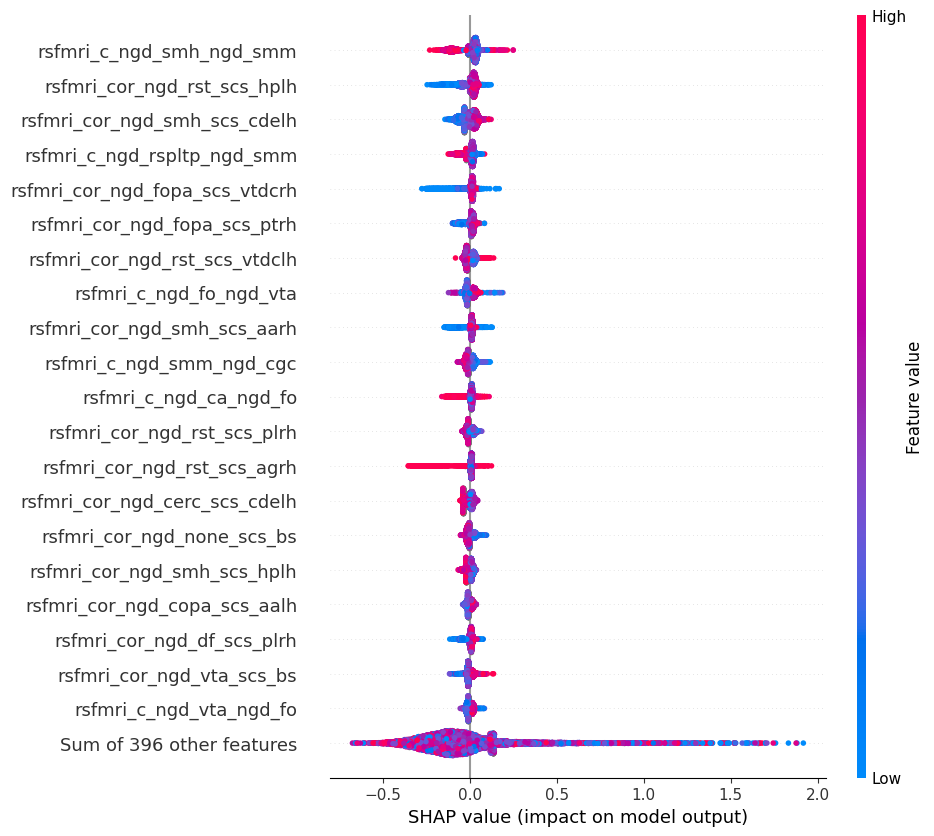

In [13]:
shap.plots.beeswarm(shap_values, max_display=21)

# SHAP dependence plots

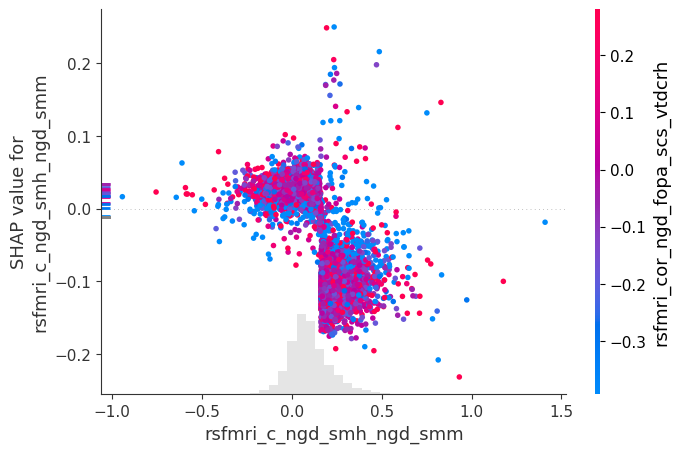

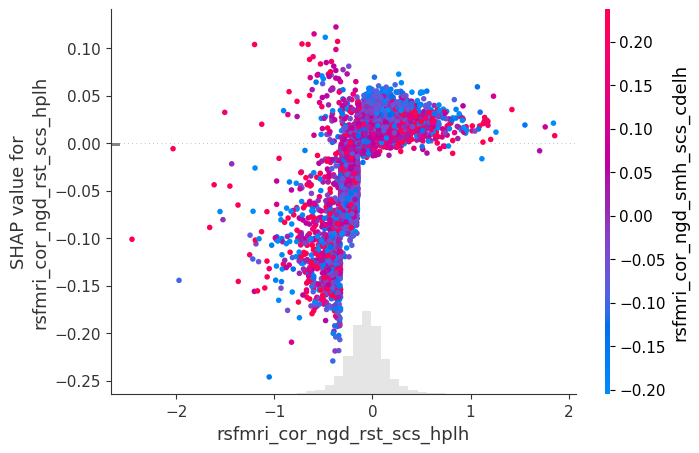

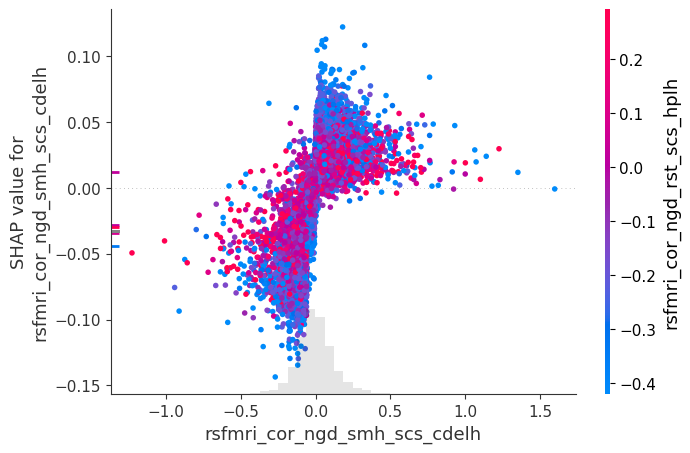

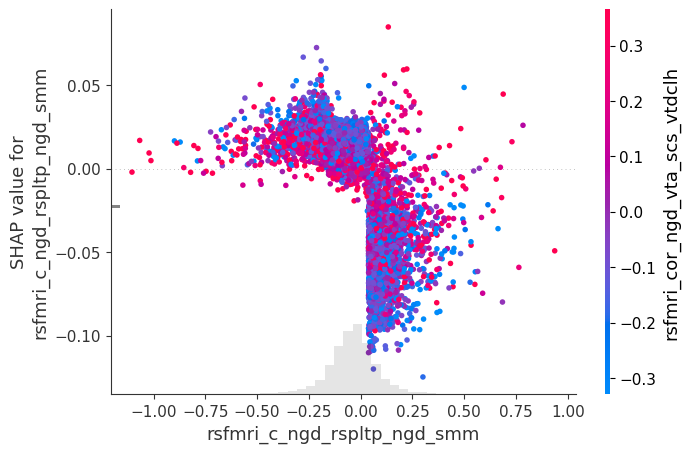

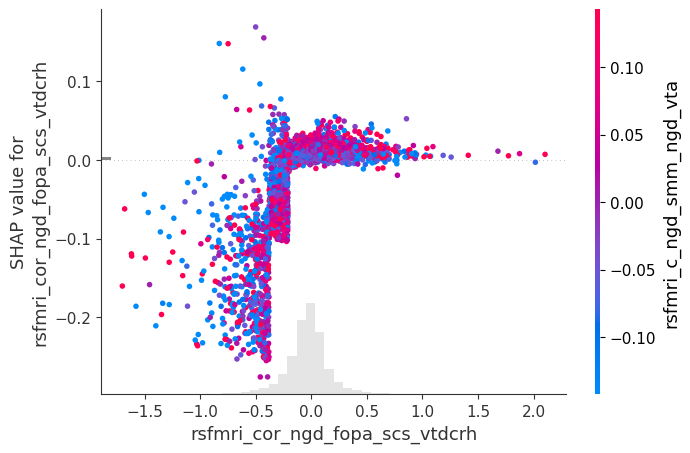

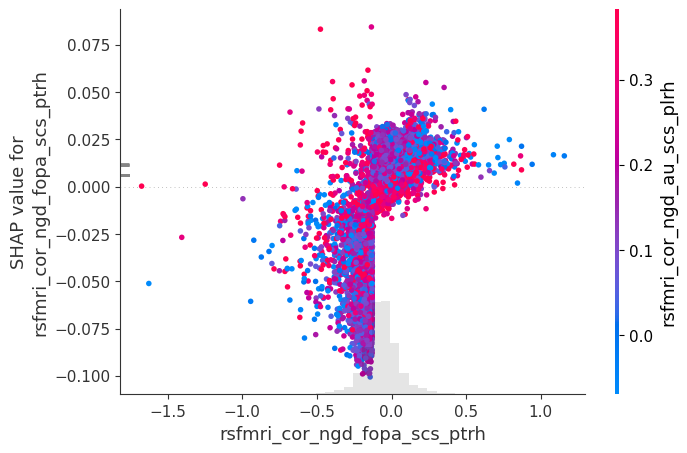

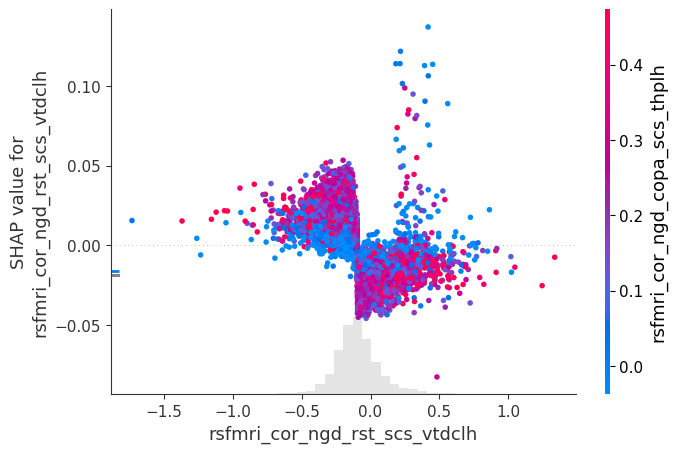

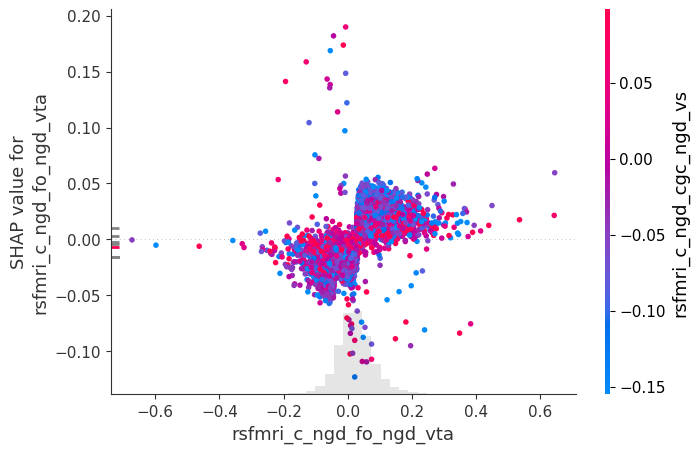

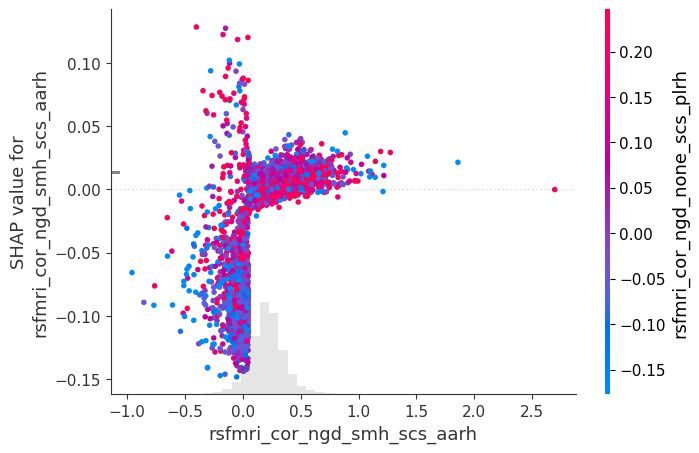

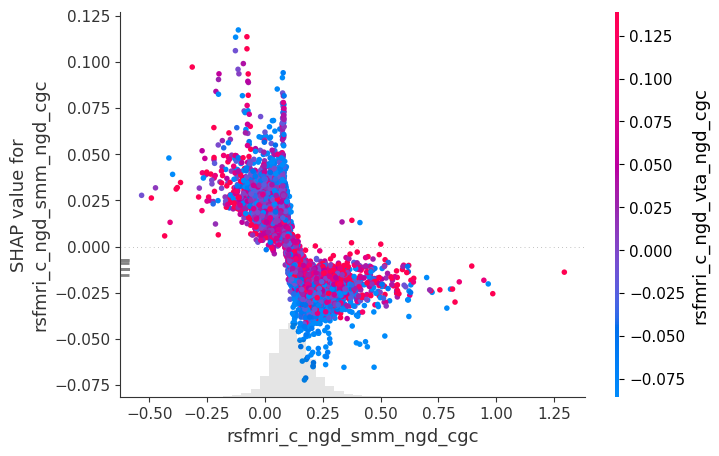

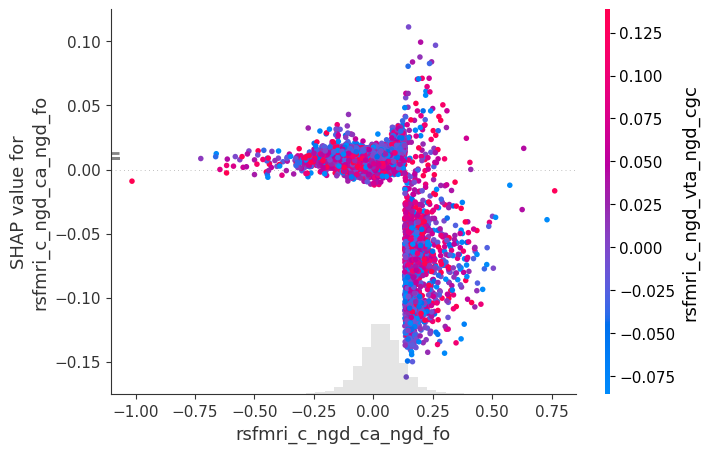

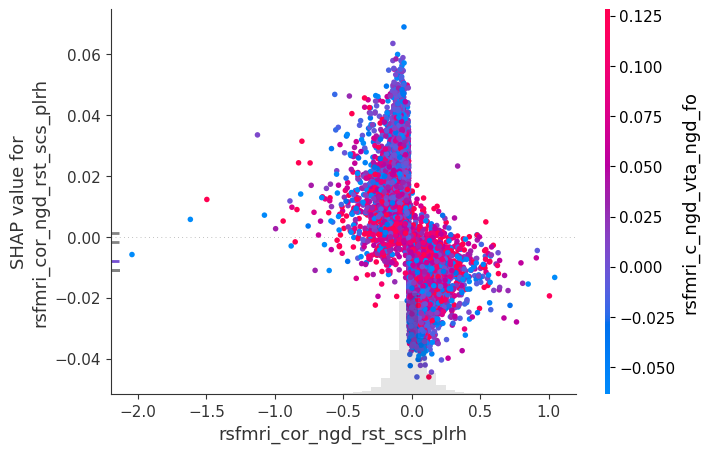

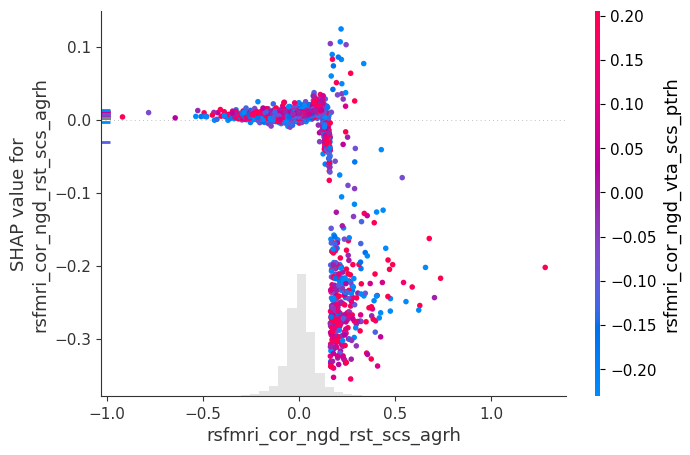

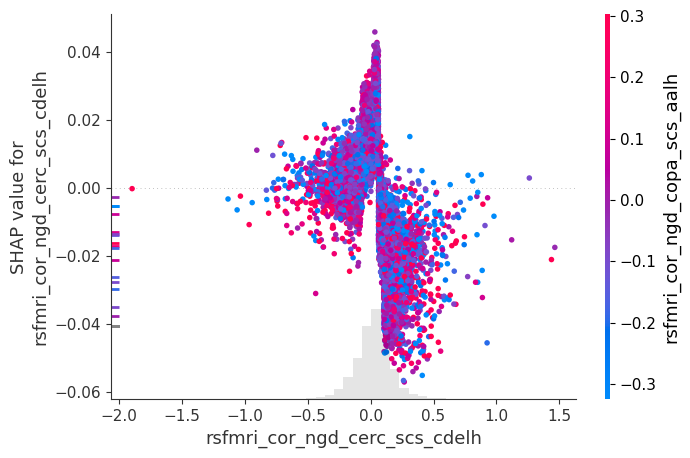

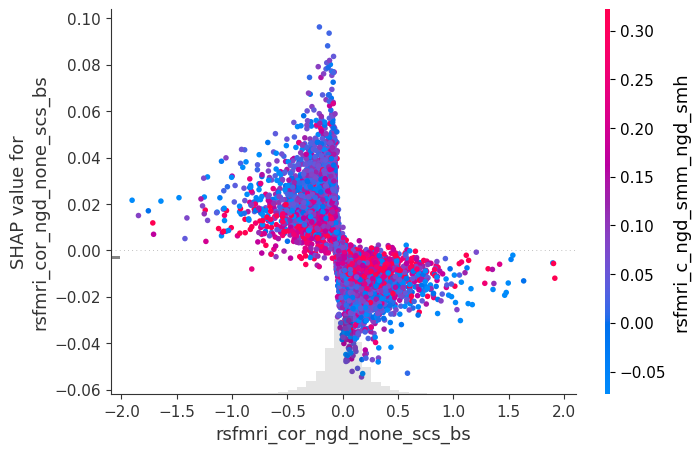

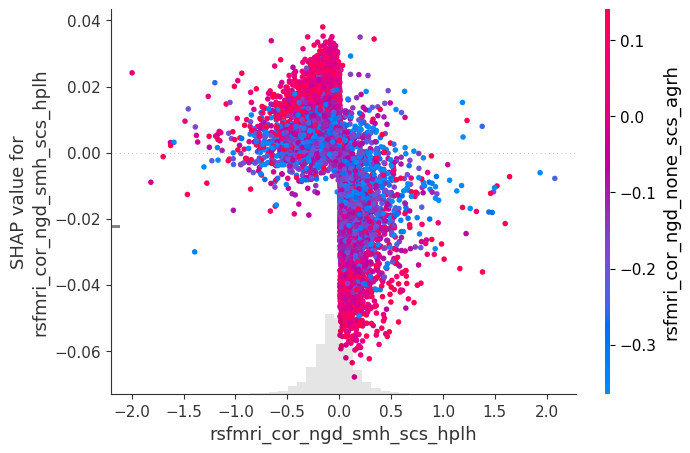

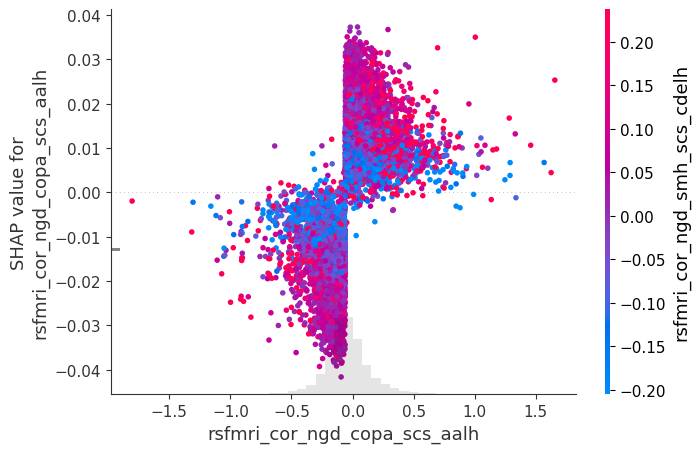

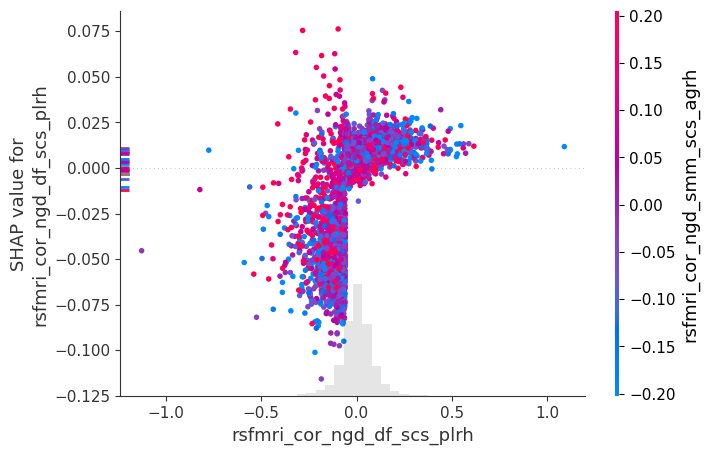

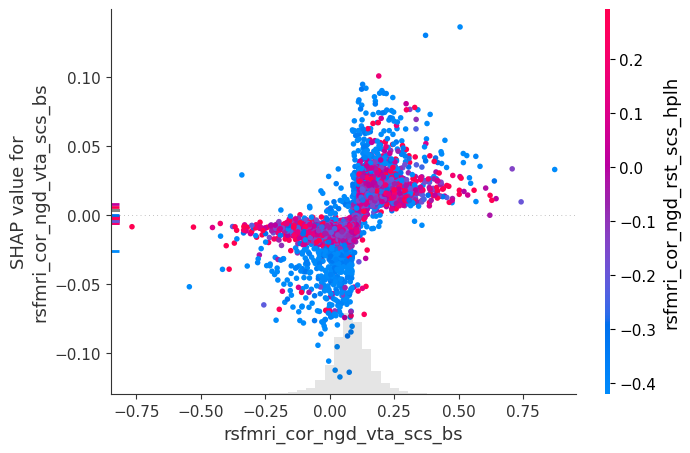

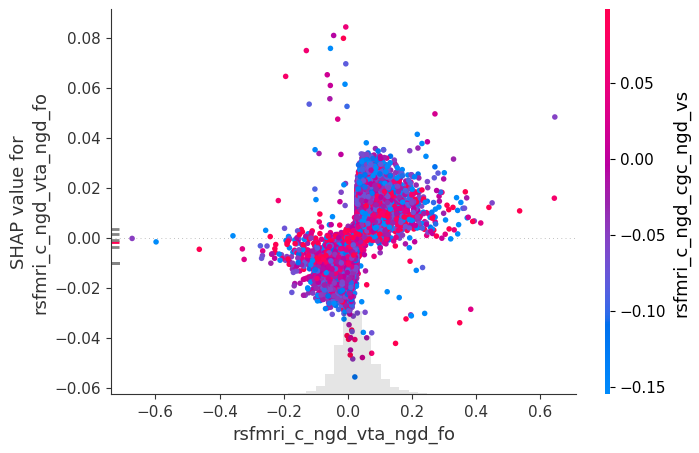

In [14]:
top_inds = np.argsort(-np.sum(np.abs(shap_values.values), 0))
for i in range(20):
    shap.plots.scatter(shap_values[:, top_inds[i]], color=shap_values)